## Packages

In [1]:
import numpy as np                                # scientific computing toolkit
import pandas as pd                               # data analysis toolkit
import scanpy as sc                               # scanpy is referred to with sc.***
import matplotlib.pyplot as plt                   # Matplotlib is referred to with plt.***
from scipy import stats                           # for linear regressions
import seaborn as sns                             # for easy heatmaps
import scirpy as ir                               # TCR analysis
#import scvelo as scv

sc.settings.verbosity = 3                         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()                         # check if all needed versions are installed and up to date (old: print_Versions(), changed in new version of scanpy)
results_directory = './Analysis_output/'
results_file = results_directory + '/results_file/write/results.h5ad'             # the file that will store the analysis results

C:\ProgramData\Miniconda3\envs\as_tcr_scripts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.logging.print_header()     

C:\Users\Adrian\AppData\Local\Temp\ipykernel_17488\2587738908.py:1: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
numpy,2.1.1
pandas,2.3.0
scanpy,1.11.3
matplotlib,3.10.6
scipy,1.15.3
seaborn,0.13.2
scirpy,0.12.2
Component,Info
Python,"3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]"
OS,Windows-11-10.0.26200-SP0


In [3]:
pd.reset_option("^display")

## Directory variables

In [4]:
import glob
import os
from pathlib import Path

sample_directory = './gex_vdj/'
analysis_info = './analysis_info/'
adata_directory = './Annotated_files/'

In [5]:
plt.rcParams['figure.figsize']=(6,6) #rescale figures
### you can set a default figure directory here for saving output
sc.settings.figdir = "./analysis_output/figures_scanpy/"
## Figure directory for matplotlib figures/axes
save_figure_sc = "./analysis_output/figures_scanpy/"
#Use
#plt.savefig(save_figure + 'image.pdf')
save_figure_ir = "./analysis_output/figures_scirpy/"
#csv directory
read_csv = './analysis_output/saved_tables/'
save_csv = r'./analysis_output/saved_tables/'

## Load data

In [6]:
# define sample metadata. Usually read from a file.
samples = {
    "2_m45": {"experiment": "2_m45", "group": "mcmv_exp2"},
    #"m45_1": {"experiment": "3_m45", "group": "mcmv_exp3"},
    #"m45_2_2": {"experiment": "4_m45", "group": "mcmv_exp4"},
    #"m45_2_1": {"experiment": "5_m45", "group": "mcmv_exp4"},
}

In [7]:
adatas = []

In [8]:
# Create a list of AnnData objects (one for each sample)
for sample, sample_meta in samples.items():
    adata = sc.read(f'{adata_directory}/{sample}_hash_solo.h5ad')
    adata.obs['mouse_concat'] = adata.obs.mouse.astype(str) + '_' + adata.obs.experiment.astype(str)
    adata.obs['mouse_concat'] = adata.obs['mouse_concat'].astype('category')
    adata.obs['isolated_specificity'] = 'M45'
    adatas.append(adata)
    

## Concatenation

In [9]:
adata = adatas[0].copy()

In [10]:
import gc
del adatas
gc.collect()

31

In [11]:
key = samples["2_m45"]["experiment"]

adata.obs_names = [
    f"{bc}-{key}"
    for bc in adata.obs_names
]

In [12]:
adata.obs['isolated_specificity'].unique()

array(['M45'], dtype=object)

In [13]:
adata.raw = adata.copy()

In [14]:
adata.layers['counts'] = adata.X.copy()

### Cell cycle scoring

C:\Users\Adrian\AppData\Local\Temp\ipykernel_17488\3454730614.py:7: FutureWarning: The specified parameters ('s_genes', 'g2m_genes') are no longer positional. Please specify them like `s_genes=0         Mcm5
1         Pcna
2         Tyms
3         Fen1
4         Mcm2
5         Mcm4
6         Rrm1
7          Ung
8        Gins2
9         Mcm6
10       Cdca7
11         Dtl
12       Prim1
13       Uhrf1
14      Mlf1ip
15       Hells
16        Rfc2
17        Rpa2
18        Nasp
19    Rad51ap1
20        Gmnn
21       Wdr76
22        Slbp
23       Ccne2
24        Ubr7
25       Pold3
26        Msh2
27       Atad2
28       Rad51
29        Rrm2
30       Cdc45
31        Cdc6
32        Exo1
33       Tipin
34       Dscc1
35         Blm
36    Casp8ap2
37        Usp1
38       Clspn
39       Pola1
40      Chaf1b
41       Brip1
42        E2f8
43       Hmgb2
44        Cdk1
45      Nusap1
Name: genes, dtype: object`
  sc.tl.score_genes_cell_cycle(adata, s_genes.genes, g2m_genes.genes)
genes are not in va

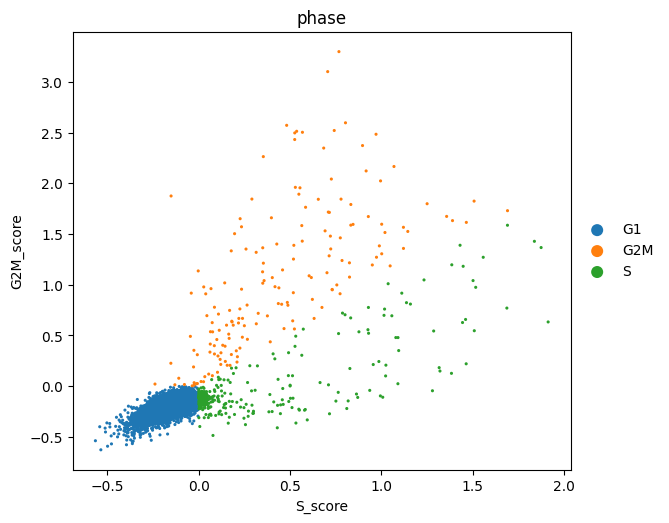

In [15]:
cc_genes=pd.read_csv(analysis_info+'regev_lab_cell_cycle_genes.txt', header=None, names=['genes'])
cc_genes['genes']=cc_genes['genes'].str.lower().str.capitalize() #mouse gene annotation
s_genes=cc_genes[:46]
g2m_genes=cc_genes[47:]
s_genes.columns=['genes']
g2m_genes.columns=['genes']
sc.tl.score_genes_cell_cycle(adata, s_genes.genes, g2m_genes.genes)
sc.pl.scatter(adata, x='S_score', y='G2M_score', color='phase', size=20)

### Normalize gene expression and save to layers

Select count matrix for different normalization methods, keep raw count of all genes, normalize only on HVGs and save to layers

Select HVGs

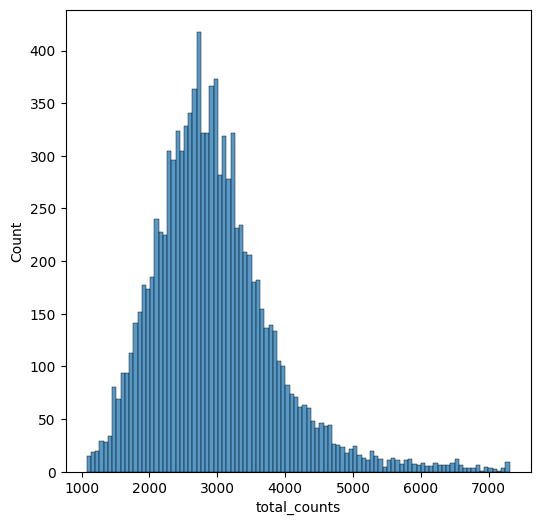

In [16]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

### Log1p normalization

In [17]:
#old target sum during HVG only selection
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p_norm"] = adata.X.copy()

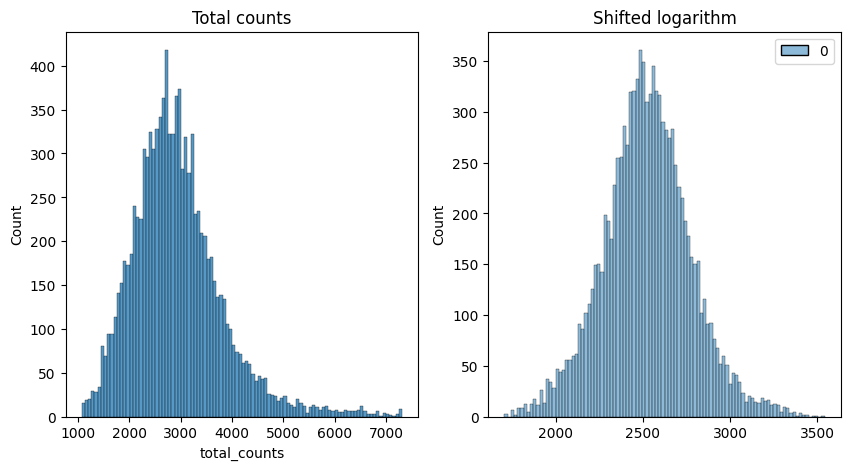

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

### Analytic pearson residuals

In [19]:
from scipy.sparse import csr_matrix, issparse
analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
adata.layers["analytic_pearson"] = csr_matrix(analytic_pearson["X"])

C:\Users\Adrian\AppData\Local\Temp\ipykernel_17488\1996927702.py:2: UserWarning: `normalize_pearson_residuals()` expects raw count data, but non-integers were found.
  analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
C:\ProgramData\Miniconda3\envs\as_tcr_scripts\Lib\site-packages\scanpy\experimental\pp\_normalization.py:76: RuntimeWarning: invalid value encountered in divide
  residuals = diff / np.sqrt(mu + mu**2 / theta)


In [20]:
%%time
#for some gene expressions in cells, analytic pearson residuals can't be calculated
nan_array = np.argwhere(np.isnan(analytic_pearson['X']))
entries = np.unique(nan_array[:,1]).tolist()
len(entries)

CPU times: total: 5.81 s
Wall time: 5.79 s


14159

In [21]:
%%time
pearson = np.delete(analytic_pearson['X'], entries, axis=1)
np.isnan(pearson).sum()

CPU times: total: 3.98 s
Wall time: 3.99 s


np.int64(0)

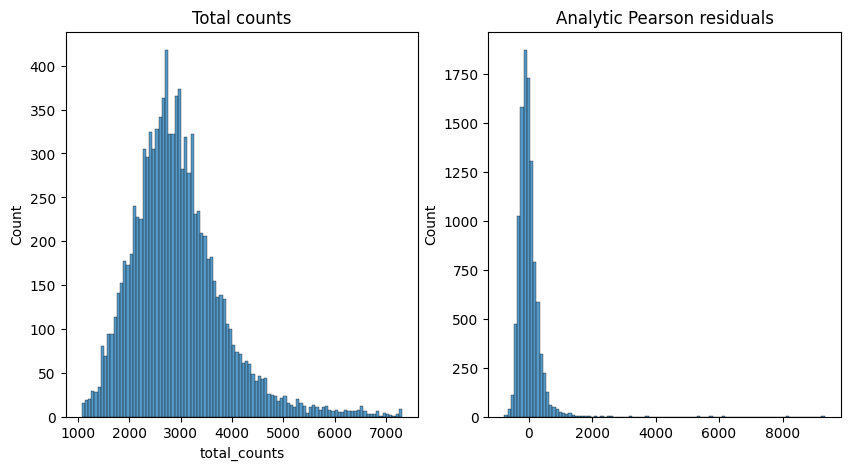

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    pearson.sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Analytic Pearson residuals")
plt.show()

### HVG selections

In [23]:
adata.X = adata.layers['counts'].copy()

In [24]:
sc.experimental.pp.highly_variable_genes(
        adata, flavor="pearson_residuals", n_top_genes=5000, chunksize=400
    )

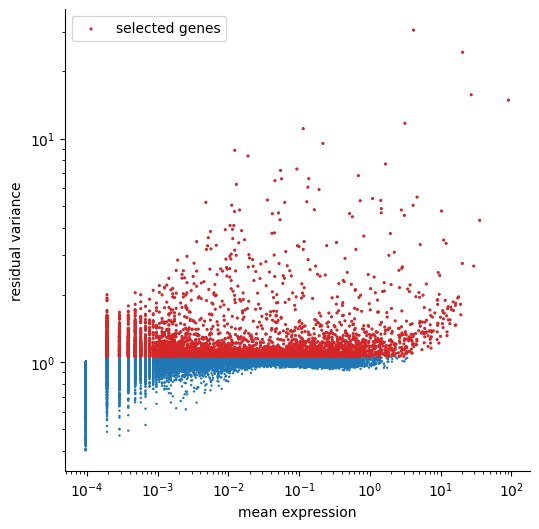

In [25]:
fig, ax = plt.subplots(figsize=(6,6))

hvgs = adata.var["highly_variable"]

ax.scatter(
    adata.var["means"], adata.var["residual_variances"], s=3, edgecolor="none")

ax.scatter(
    adata.var["means"][hvgs],
    adata.var["residual_variances"][hvgs],
    c="tab:red",
    label="selected genes",
    s=5,
    edgecolor="none",
)
ax.set_xscale("log")
ax.set_xlabel("mean expression")
ax.set_yscale("log")
ax.set_ylabel("residual variance")
#ax.set_title(adata.uns["name"])

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
                       
plt.legend()

### Compute PCA and UMAP

In [26]:
adata.X = adata.layers["log1p_norm"]

In [27]:
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)

C:\ProgramData\Miniconda3\envs\as_tcr_scripts\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


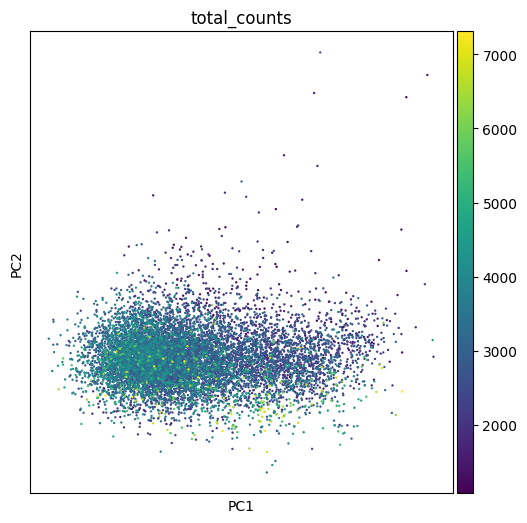

In [28]:
sc.pl.pca_scatter(adata, color="total_counts")

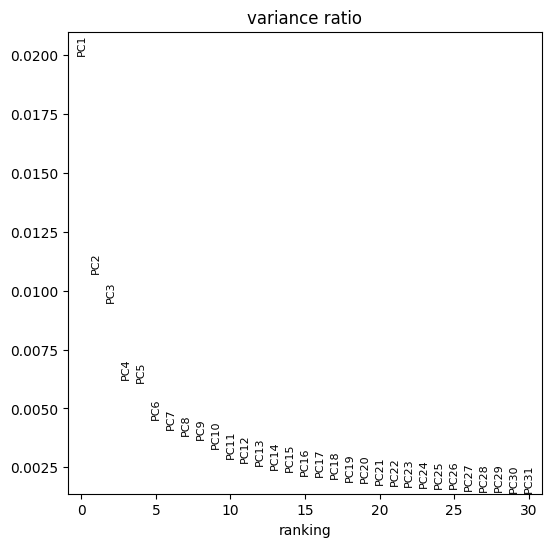

In [29]:
n_cells = len(adata)
sc.pl.pca_variance_ratio(adata)

In [30]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

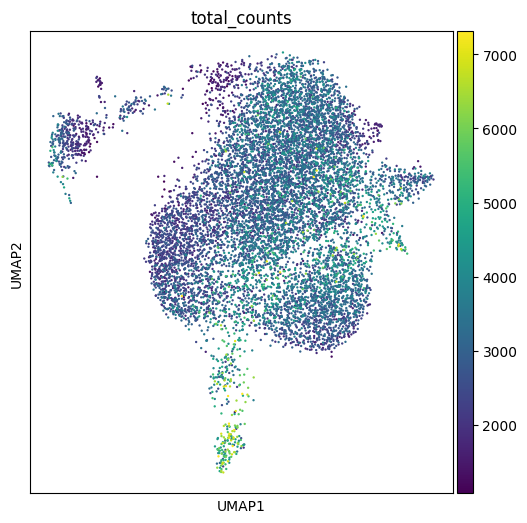

In [31]:
sc.pl.umap(adata, color="total_counts")

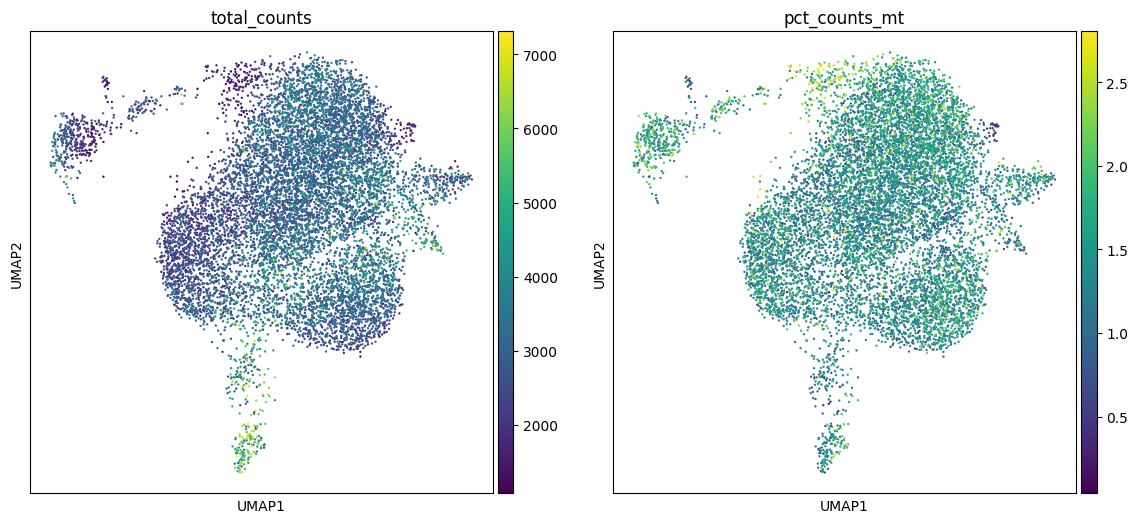

In [32]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt"],
)

### Bach correction

Batch correction

In [33]:
adata.obs.group.unique().tolist()

['mcmv_exp2']

### Integrate TCR expression

In [34]:
ir.tl.chain_qc(adata)

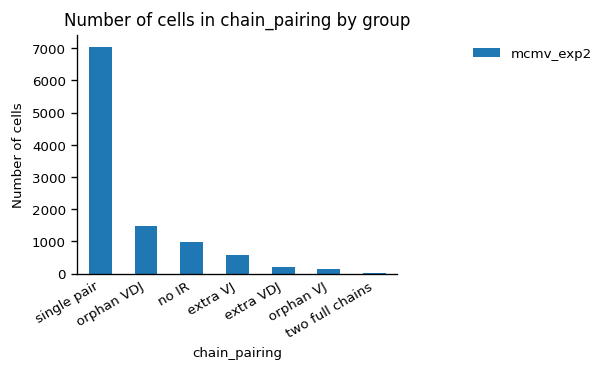

In [35]:
ax=ir.pl.group_abundance(adata, groupby='chain_pairing', target_col='group')
#ax.figure.savefig(save_figure_ir + 'chain_pairing_exp.eps')

<Axes: title={'center': 'has_ir'}, xlabel='UMAP1', ylabel='UMAP2'>

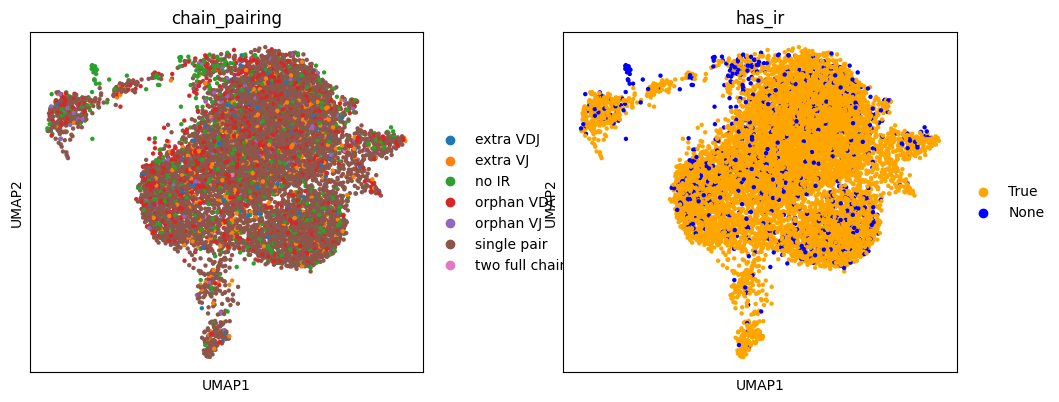

In [36]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
fig.tight_layout(w_pad=7)
sc.pl.umap(adata, color='chain_pairing', ax=ax[0], show=False, s=40)
sc.pl.umap(adata, color='has_ir', palette=['orange', 'blue'], ax=ax[1], show=False, s=40)

#fig.savefig(save_figure_ir + 'UMAP_chain_pairing.eps')

Remove orphan and non-detected TCRs

In [37]:
before_tcr = adata.n_obs

In [38]:
adata = adata[adata.obs["has_ir"] != 'None',:]
adata = adata[~adata.obs["chain_pairing"].isin(["orphan VDJ", "orphan VJ"]), :]

In [39]:
after_tcr = adata.n_obs

In [40]:
print("Cells filtered out due to lack of full TCR expression: " + str(before_tcr-after_tcr))

Cells filtered out due to lack of full TCR expression: 2590


C:\ProgramData\Miniconda3\envs\as_tcr_scripts\Lib\site-packages\scanpy\plotting\_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


<Axes: title={'center': 'has_ir'}, xlabel='UMAP1', ylabel='UMAP2'>

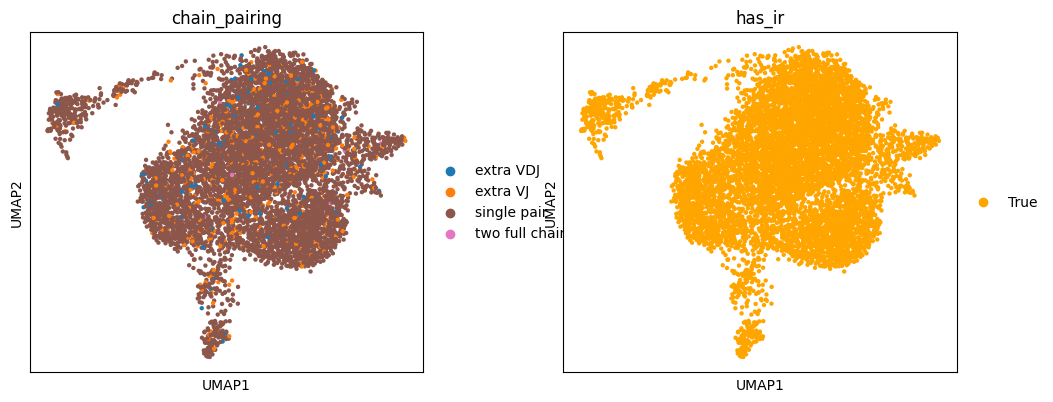

In [41]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
fig.tight_layout(w_pad=7)
sc.pl.umap(adata, color='chain_pairing', ax=ax[0], show=False, s=40)
sc.pl.umap(adata, color='has_ir', palette=['orange', 'blue'], ax=ax[1], show=False, s=40)
#fig.savefig(save_figure_ir + 'UMAP_chain_pairing_After_filter.eps')

### Clustering the neighborhood graph

In [42]:
adata.layers

Layers with keys: counts, log1p_norm, analytic_pearson

C:\Users\Adrian\AppData\Local\Temp\ipykernel_17488\2648840300.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.2)


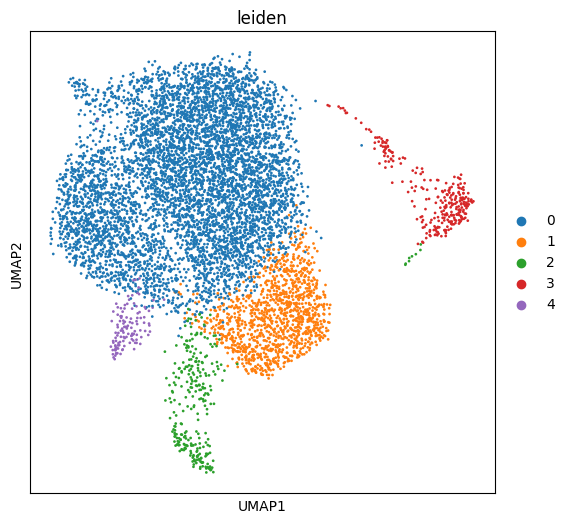

In [43]:
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 0.2)
sc.pl.umap(adata, color='leiden')

In [44]:
from sklearn.metrics import silhouette_score
def titrate_leiden_resolution(adata):
    res_array=list(np.round(np.linspace(.1, 2, 20),1))
    silhoutte_list=list()
    sc.settings.verbosity = 1
    for i,res in enumerate(res_array):
        sc.tl.leiden(adata, resolution=res)
        if adata.obs.leiden.unique().shape[0]>2:
            silhoutte_list.append(silhouette_score(adata.obsm['X_umap'],
                    adata.obs[f'leiden'],
                    metric='euclidean'))
        else:
            silhoutte_list.append(np.nan)
        print(str(np.round(((i+1)/len(res_array))*100,1))+"%", end="\r", flush=True)
    sns.lineplot(x=res_array, y=silhoutte_list, color='black', markers='o')

define leiden res:

In [45]:
sc.tl.leiden(adata, resolution = 0.4)

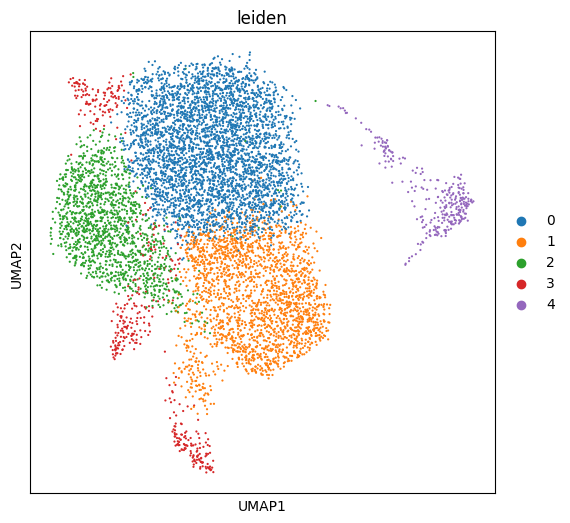

In [46]:
sc.pl.umap(adata, color='leiden', s=10) #save='_leiden_only.pdf'

In [47]:
#adata.obs.leiden.value_counts()

In [48]:
#remove single cell outliers for DEG
before = adata.n_obs
df = pd.DataFrame(adata.obs.leiden.value_counts())
leiden_remove = df[df['count']<2].index.tolist()
adata = adata[~adata.obs.leiden.isin(leiden_remove)].copy()
after =  adata.n_obs
print('removed: ' + str(before-after) + 'cells')

removed: 0cells


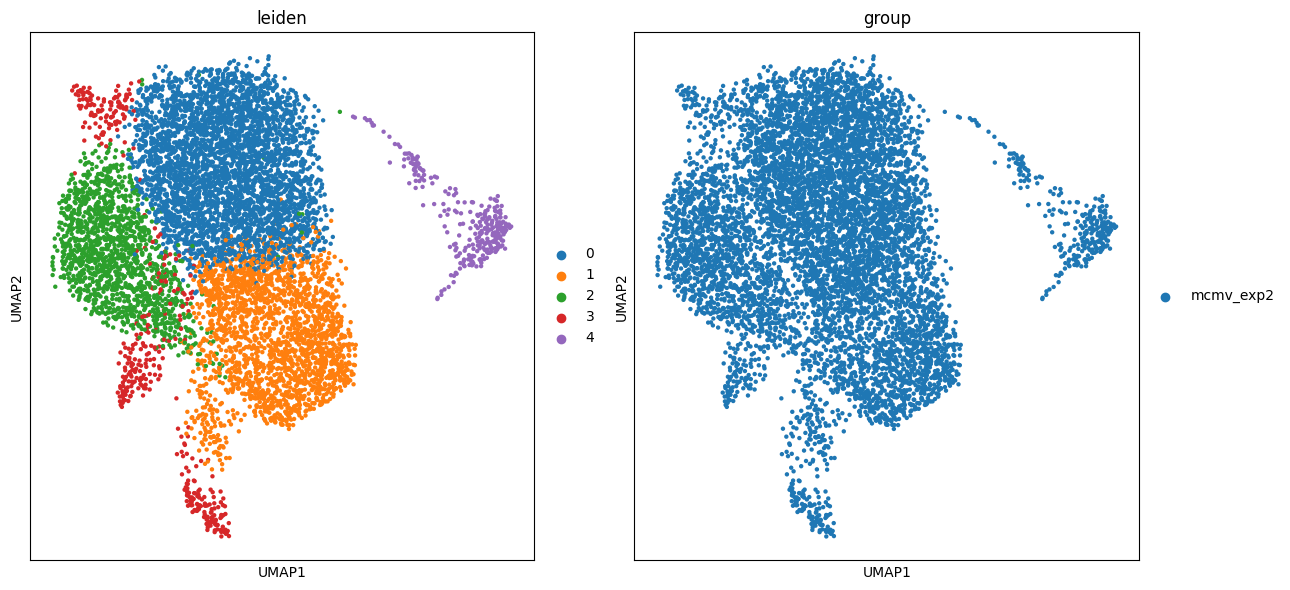

In [49]:
fig, ax = plt.subplots(ncols=2, figsize=(13,6))

sc.pl.umap(adata, color='leiden', ax=ax[0], show=False, s=40)
sc.pl.umap(adata, color='group', ax=ax[1], show=False, s=40, palette='tab10')

fig.tight_layout()
#fig.savefig(save_figure_ir + 'UMAP_leiden_batch.eps')

In [50]:
adata.X = adata.layers["log1p_norm"].copy()

In [51]:
adata.layers

Layers with keys: counts, log1p_norm, analytic_pearson

dendrogram done


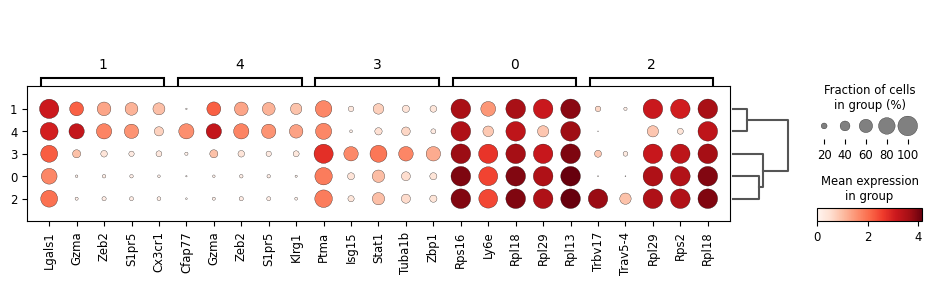

In [52]:
sc.tl.dendrogram(adata, groupby='leiden')
print("dendrogram done")
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test', use_raw=False,)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, show=True, use_raw=False,)#, save='_rank_genes_leiden.eps')

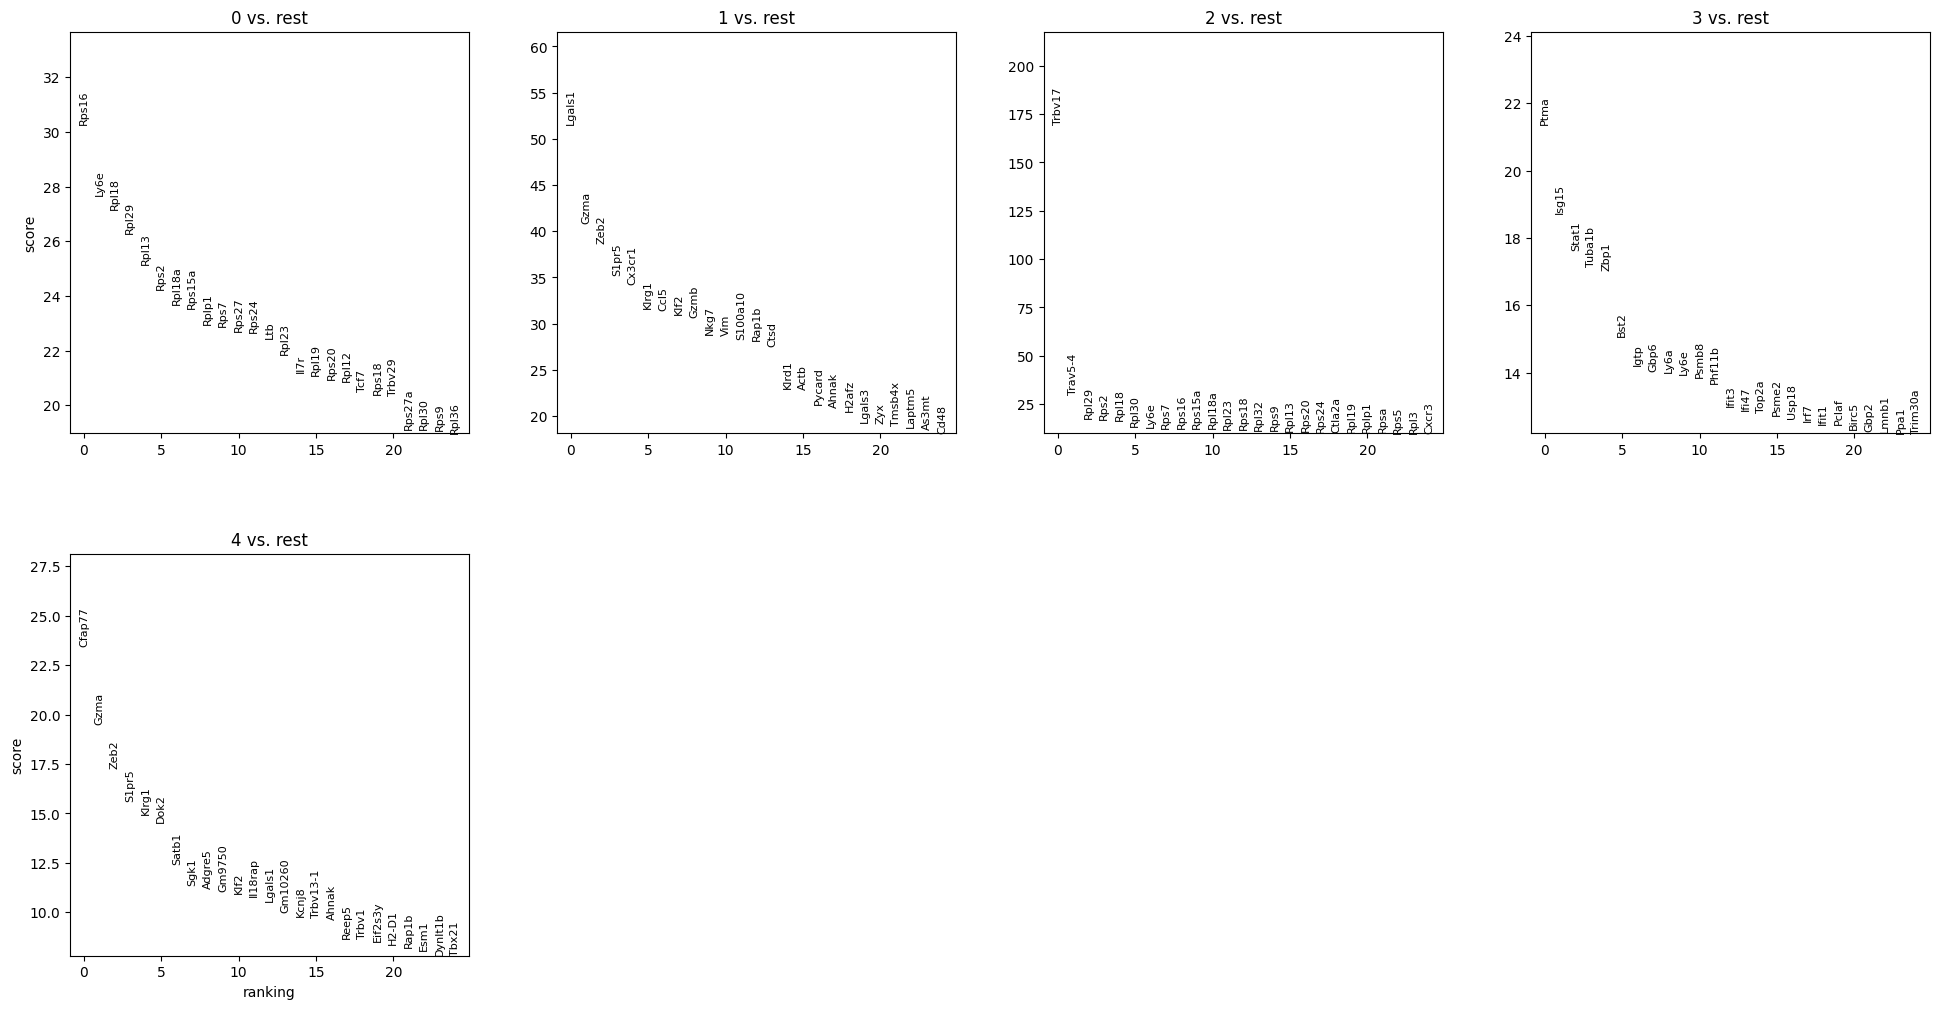

In [53]:
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False,)# save='_rank_genes_leiden_gene_names.eps')

In [54]:
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
results_df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(100)
#results_df.to_excel('./Analysis_output/deg_leiden.xls')

## Clonotype integration

Annotate clono type size by donor

In [55]:
exp_list = adata.obs.experiment.unique().tolist()
mouse_list = adata.obs.mouse_concat.unique().tolist()

In [56]:
adata.obs['tra_id'] = adata.obs['IR_VJ_1_v_call'].astype(str) + '_' + adata.obs['IR_VJ_1_j_call'].astype(str) + '_' + adata.obs['IR_VJ_1_junction_aa'].astype(str)
adata.obs['trb_id'] = adata.obs['IR_VDJ_1_v_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_j_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_junction_aa'].astype(str)
adata.obs['tcr_id'] = adata.obs['tra_id'] + '__' + adata.obs['trb_id']



In [57]:
adata.obs["TCR_expansion"] = (
    adata.obs
    .groupby(["mouse", "tcr_id"], sort=False, observed=True)["tcr_id"]
    .transform("size")
)
adata.obs['clonotype_size_mouse']=adata.obs['TCR_expansion'].copy()

In [58]:
adata.obs["isolated_specificity"] = 'M45'
adata.obs["sequencing_specificity"] = "below_threshold"
exp=2
tcr_list = adata.obs.tcr_id[adata.obs.TCR_expansion>=exp].unique().tolist()
mask = adata.obs.tcr_id.isin(tcr_list)
adata.obs.loc[mask,"sequencing_specificity"] = "M45"

In [59]:
adata.obs['NAME'] = adata.obs.index.copy()
adata.obs['donor_id'] = adata.obs['mouse_concat']
adata.obs['biosample_id'] = adata.obs['experiment']
adata.obs['species'] = 'NCBITaxon_10090'
adata.obs['species__strain'] = 'C57BL/6'
adata.obs['species__ontology_label'] = 'Mus musculus'
adata.obs['disease'] = 'MONDO_0005132'
adata.obs['disease__strain'] = 'murine_cytomegalovirus_wildtype'
adata.obs['disease__ontology_label'] = 'cytomegalovirus infection'
adata.obs['disease__epitope'] = 'HGIRNASFI'
adata.obs['disease__antigen'] = 'M45'
adata.obs['disease__timepoint'] = 'd8'
adata.obs['organ'] = 'UBERON_0002106'
adata.obs['organ__ontology_label'] = 'spleen'
adata.obs['library_preparation_protocol'] = 'EFO_0009900'
adata.obs['library_preparation_protocol__ontology_label'] = "10x 5' v2"
adata.obs['cell_type'] = "CL_0000625"
adata.obs['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
adata.obs['sex'] = 'female'


In [60]:
adata_file = 'processed_adata_M45_1.h5ad'
adata.write(adata_directory+adata_file)

In [1]:
import matplotlib_inline.backend_inline as backend_inline
import IPython.display as disp
# Make set_matplotlib_formats available where Scanpy expects it
disp.set_matplotlib_formats = backend_inline.set_matplotlib_formats

import numpy as np                                # scientific computing toolkit
import pandas as pd                               # data analysis toolkit
import scanpy as sc                               # scanpy is referred to with sc.***
import matplotlib.pyplot as plt                   # Matplotlib is referred to with plt.***
from scipy import stats                           # for linear regressions
import seaborn as sns                             # for easy heatmaps
import scirpy as ir                               # TCR analysis
#import scvelo as scv

sc.settings.verbosity = 3                         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()                         # check if all needed versions are installed and up to date (old: print_Versions(), changed in new version of scanpy)
results_directory = './Analysis_output/'
results_file = results_directory + '/results_file/write/results.h5ad'             # the file that will store the analysis results

#update annotation

import glob
import os
from pathlib import Path

sample_directory = './GEX_VDJ/'
analysis_info = './analysis_info/'
adata_directory = './Annotated_files/'

adata_file = 'processed_adata_M45_1.h5ad'
adata = sc.read(adata_directory+adata_file)

adata.obs['mouse'] = adata.obs['mouse'].astype('string') + '_' +  adata.obs['isolated_specificity'].astype('string')
adata.obs['donor_id'] = adata.obs['mouse']
adata.obs['species__ontology_label'] = 'Mus musculus'


C:\Users\wwspa\miniconda3\envs\tcr_scripts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_obs = pd.DataFrame(adata.obs)#.to_csv('./obs_df_OVA.csv', index=False)
for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")

In [3]:
from preprocess_tcr_2 import preprocess_tcr_vj_vdj
df = preprocess_tcr_vj_vdj(df_obs)
df.to_csv('./obs_df_M45_1.csv', index=False)

In [4]:
adata.write(adata_directory+adata_file)

In [5]:
adata

AnnData object with n_obs × n_vars = 7847 × 32285
    obs: 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'experiment', 'gro